In [1]:
import torch 
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from gluonts.dataset.common import ListDataset

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
import yfinance as yf

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Portfolio + Aux Variable Init

In [2]:
# Selected stock symbol
stock_symbol = "^N225"  # Nikkei 225 Index

index_symbol = "^VIX"  # VIX Index

# Stock Data Start and End Dates
end_date = pd.Timestamp("2026-09-01")
start_date = end_date - pd.DateOffset(years=2)

# start_date = pd.Timestamp("2020-01-01")

print(f"Fetching stock data from {start_date.date()} to {end_date.date()}")

Fetching stock data from 2024-09-01 to 2026-09-01


In [3]:
stockFetch = yf.download(stock_symbol, start=start_date, end=end_date)
indexFetch = yf.download(index_symbol, start=start_date, end=end_date)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
stockReturns = np.log1p(stockFetch['Close'].pct_change().dropna())
indexLevel = np.log1p(indexFetch['Close'].pct_change().dropna())
indexName = indexLevel.columns[0]

In [5]:
stockAux = stockReturns.squeeze()
indexLevelAlignment = pd.concat(
    [stockAux.rename("returns"), indexLevel.reindex(stockAux.index).ffill()],
    axis=1,
).dropna()

indexLevelAligned = indexLevelAlignment[indexName]

<Axes: title={'center': '^N225 Returns'}, xlabel='Date'>

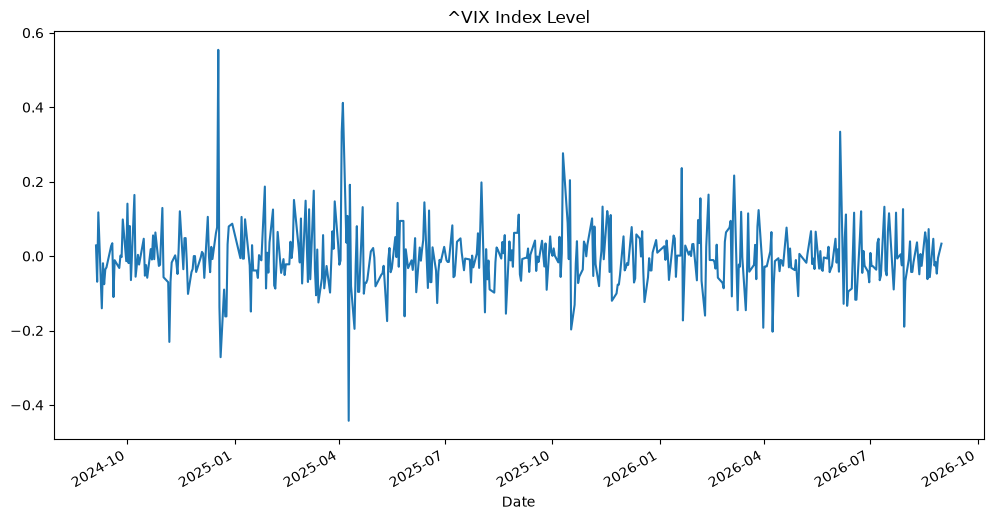

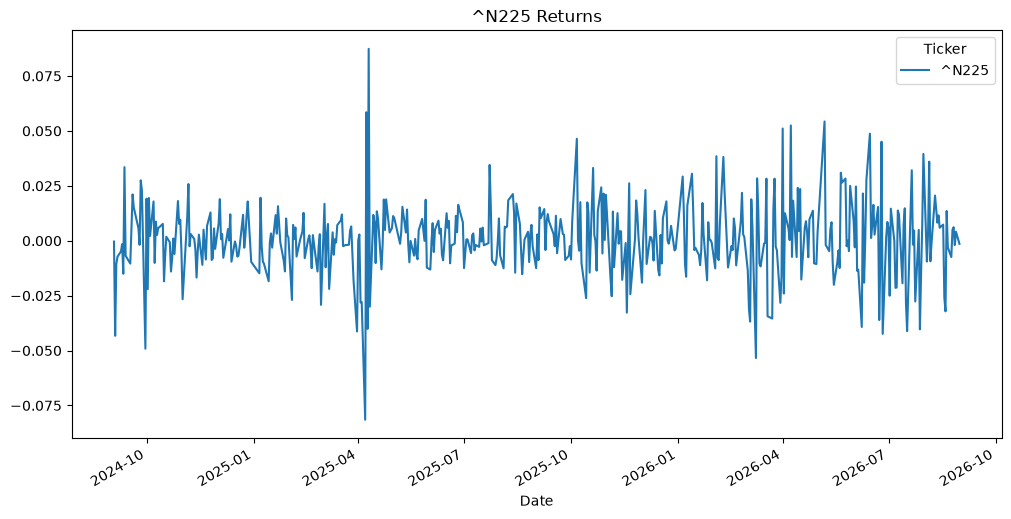

In [6]:
indexLevelAligned.plot(title=f"{index_symbol} Index Level", figsize=(12, 6))
stockReturns.plot(title=f"{stock_symbol} Returns", figsize=(12, 6))

## Foundation Model Prediction

In [7]:
moirai_module = MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-base")

### Model Configs

In [8]:
predictionLength = 10
numSamples = 5000
batchSize = 4
cap = 100  # 10000%

In [9]:
moirai_model = MoiraiForecast(
    module=moirai_module,
    prediction_length=predictionLength, 
    target_dim=1, 
    feat_dynamic_real_dim=1, # auxiliary index level as a feature
    past_feat_dynamic_real_dim=0,
    context_length=len(stockReturns)
    )

In [10]:
predictor = moirai_model.create_predictor(batch_size=batchSize)

### Cumulate each simulated return

In [11]:
def createCumulativeReturns(forecast):
    samples = forecast.samples
    cumulative_returns = np.cumsum(samples, axis=1)
    
    return cumulative_returns

def createCumulativeReturnsFromArray(forecast):
    samples = forecast
    cumulative_returns = np.cumsum(samples, axis=1)
    
    return cumulative_returns

In [12]:
def neutralizeUnrealisticReturns(returns, cap):
    mask = (returns > cap) | (returns < -cap)
    return np.where(mask, 0.0, returns)

## Measures

In [13]:
VaRQuantiles = [0.01, 0.025, 0.05]
ESQuantiles = [0.01, 0.025, 0.05]

varQuantileNames = [f"VaR_{q:0.1%}" for q in VaRQuantiles]
esQuantileNames = [f"ES_{q:0.1%}" for q in ESQuantiles]

In [14]:
def summarize_predictions(predictions):
    """Summarize log-return predictions across simulations for each forecast step."""
    values = np.asarray(predictions, dtype=float)

    # Treat a vector as one forecast step with multiple simulations.
    if values.ndim == 1:
        values = values[:, np.newaxis]
    if values.ndim != 2:
        raise ValueError("predictions must be a 1D vector or 2D matrix")

    measures = {
        "mean": np.mean(values, axis=0),
        "median": np.median(values, axis=0),
        "variance": np.var(values, axis=0),
        "min": np.min(values, axis=0),
        "max": np.max(values, axis=0),
        "skew": skew(values, axis=0),
        "kurtosis": kurtosis(values, axis=0),
    }

    for q, name in zip(VaRQuantiles, varQuantileNames):
        threshold = np.quantile(values, q, axis=0)
        measures[name] = threshold

    for q, name in zip(ESQuantiles, esQuantileNames):
        threshold = np.quantile(values, q, axis=0)
        measures[name] = np.array([
            values[values[:, step] <= threshold[step], step].mean()
            for step in range(values.shape[1])
        ])

    return measures

### Correct measures by expected evolution (T)

In [15]:
plotIndex = np.arange(1, predictionLength + 1)

linearTimeEffect = plotIndex # forcing the first one to be 1 instead of an year fraction

## Estimate the index level impact on measures

In [16]:
# indexRange = [10, 20, 30, 40, 50]
indexRange = [-0.5, -0.25, 0.25, 0.5, 1.5, 2, 3]
# shockRange = np.arange(0.2, 2, 0.05).tolist()

print(f"Index range: {indexRange}")

Index range: [-0.5, -0.25, 0.25, 0.5, 1.5, 2, 3]


In [17]:
def makeFeatureDataset(targetReturns, futureLevels):
    entries = []
    for futureIndex in futureLevels:
        fullFeature = np.concatenate(
            [indexLevelAligned, np.full(predictionLength, futureIndex, dtype=np.float32)]
        ).reshape(1, -1)
        entries.append(
            {
                "start": pd.Timestamp(indexLevelAligned.index[0]),
                "target": np.asarray(targetReturns, dtype=np.float32),
                "feat_dynamic_real": fullFeature,
            }
        )
    return ListDataset(entries, freq="B")

In [18]:
stockReturnsTarget = stockReturns.squeeze().to_numpy(dtype=np.float32)
enhancedTarget = makeFeatureDataset(stockReturnsTarget, indexRange)

/opt/homebrew/lib/python3.11/site-packages/gluonts/dataset/common.py:262: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return pd.Period(val, freq)


In [19]:
torch.manual_seed(42)
np.random.seed(42)

In [20]:
shockForecasts = list(predictor.predict(enhancedTarget, num_samples=numSamples))

/opt/homebrew/lib/python3.11/site-packages/gluonts/transform/split.py:572: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  d[self.forecast_start_field] = d[self.start_field] + i + lt


In [21]:
cap = 2 # 200%
def treatAndSummarizeForecasts(forecast):
    """Treat and summarize shock forecasts."""
    cappedReturns = neutralizeUnrealisticReturns(forecast.samples, cap)
    cumulativeLogReturns = createCumulativeReturnsFromArray(cappedReturns)
    cumulativeReturns = np.expm1(cumulativeLogReturns)
    return summarize_predictions(cumulativeReturns)


In [22]:
shockSummaries = {shock: treatAndSummarizeForecasts(forecast) for shock,forecast in zip(indexRange, shockForecasts)}

### Check shock results

### One day ahead sensibility

In [23]:
meanOneDay = [summary["mean"][0] for summary in shockSummaries.values()]
varianceOneDay = [summary["variance"][0] for summary in shockSummaries.values()]
kurtosisOneDay = [summary["kurtosis"][0] for summary in shockSummaries.values()]
skewnessOneDay = [summary["skew"][0] for summary in shockSummaries.values()]

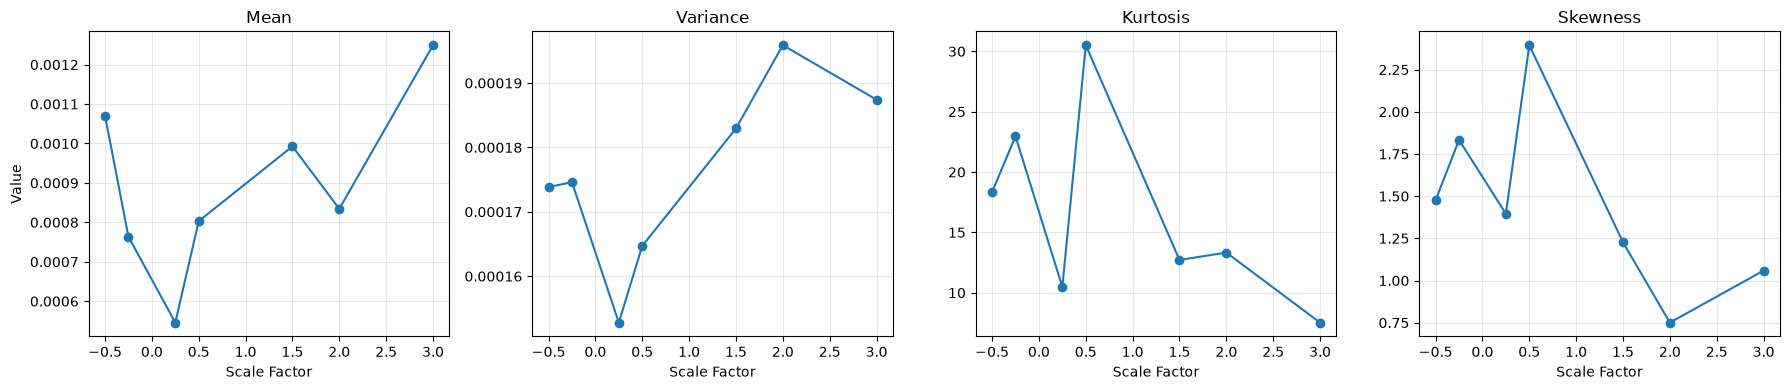

In [24]:
metrics = [
    (meanOneDay, "Mean"),
    (varianceOneDay, "Variance"),
    (kurtosisOneDay, "Kurtosis"),
    (skewnessOneDay, "Skewness"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True)

for ax, (values, title) in zip(axes, metrics):
    ax.plot(indexRange, values, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Scale Factor")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Value")
fig.tight_layout()
plt.show()


In [25]:
varsOneDay = {q: [summary[f"VaR_{q:0.1%}"][0] for summary in shockSummaries.values()] for q in VaRQuantiles}
esOneDay = {q: [summary[f"ES_{q:0.1%}"][0] for summary in shockSummaries.values()] for q in ESQuantiles}

### Scale x VaR

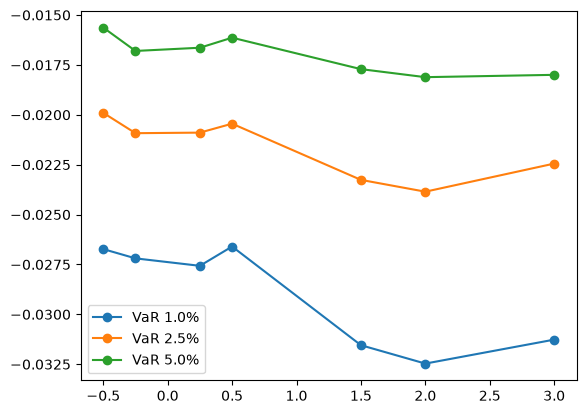

In [26]:
for q, values in varsOneDay.items():
    plt.plot(indexRange, values, marker="o", label=f"VaR {q:0.1%}")

plt.legend()

### Scale x ES

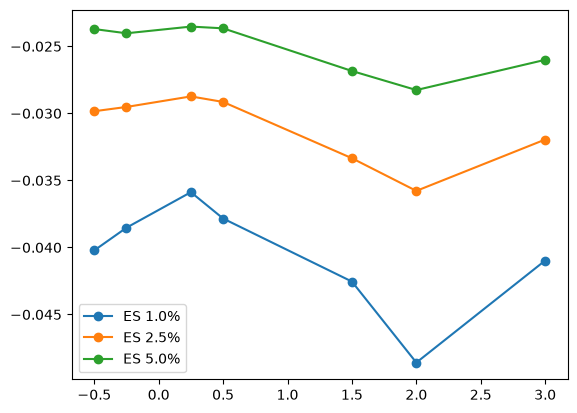

In [27]:
for q, values in esOneDay.items():
    plt.plot(indexRange, values, marker="o", label=f"ES {q:0.1%}")

plt.legend()

### Visualize the predicted 1D distributions

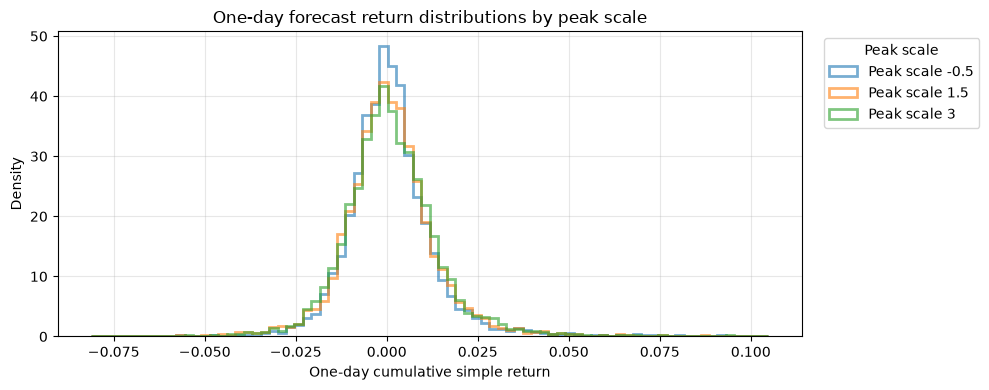

In [35]:
oneDayDistributions = []
for forecast in shockForecasts:
    cappedLogReturns = neutralizeUnrealisticReturns(forecast.samples, 0.10) # cap to 15% for visualization
    oneDayDistributions.append(np.expm1(cappedLogReturns[:, 0]))

allOneDayReturns = np.concatenate(oneDayDistributions)
bins = np.linspace(allOneDayReturns.min(), allOneDayReturns.max(), 81)

fig, ax = plt.subplots(figsize=(10, 4))

graphRange = [-0.5, 1.5, 3.0]
peakIndexes = np.flatnonzero(np.isin(indexRange, graphRange))

for gRange, returnIndex in zip(graphRange, peakIndexes):
    ax.hist(
        oneDayDistributions[returnIndex],
        density=True,
        bins=bins,
        label=f"Peak scale {gRange:g}",
        histtype="step",
        linewidth=2,
        alpha=0.6,
    )

ax.set_title("One-day forecast return distributions by peak scale")
ax.set_xlabel("One-day cumulative simple return")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
ax.legend(title="Peak scale", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

### Mean over time with no time affect

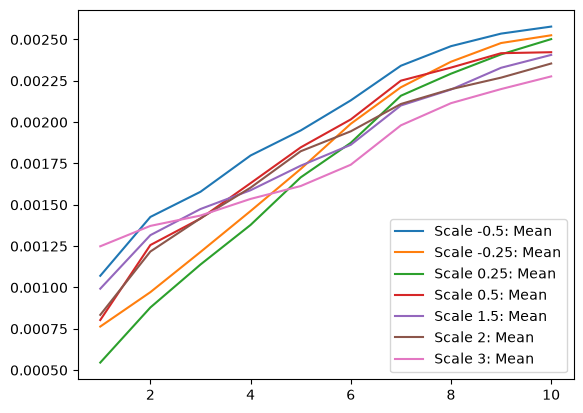

In [29]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["mean"]/linearTimeEffect, label=f"Scale {shock}: Mean")

plt.legend()

### Variance over time with no time affect

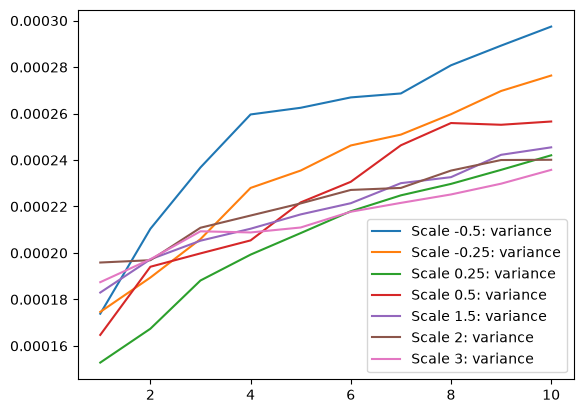

In [30]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["variance"]/linearTimeEffect, label=f"Scale {shock}: variance")

plt.legend()

### Kurtosis over time

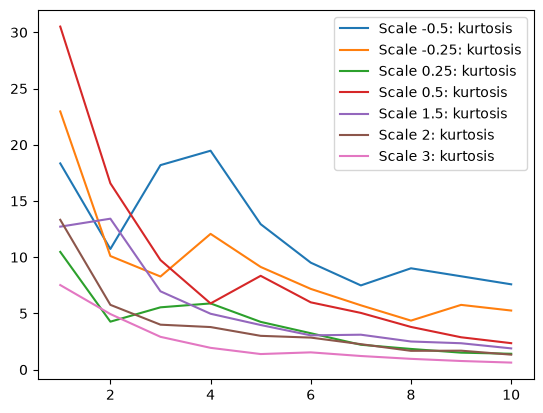

In [31]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["kurtosis"], label=f"Scale {shock}: kurtosis")

plt.legend()

### Skewness over time

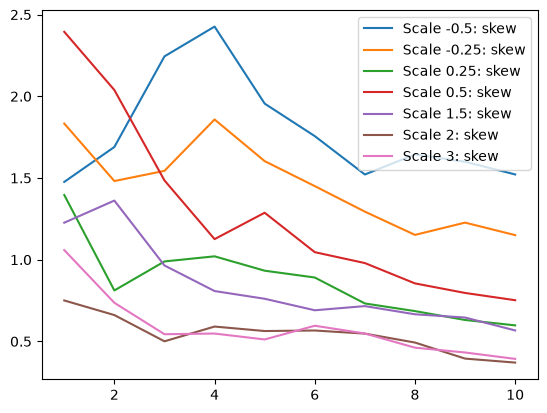

In [32]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["skew"], label=f"Scale {shock}: skew")

plt.legend()

### VaR 5% over time

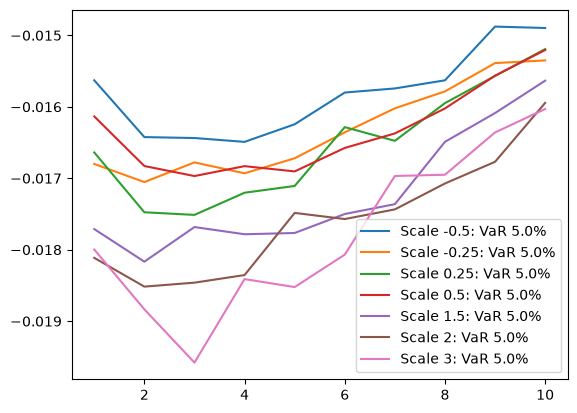

In [33]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["VaR_5.0%"]/np.sqrt(linearTimeEffect), label=f"Scale {shock}: VaR 5.0%")

plt.legend()

### ESVaR 5% over time

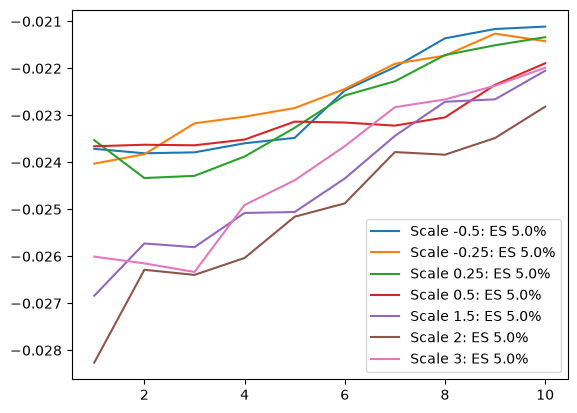

In [34]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["ES_5.0%"]/np.sqrt(linearTimeEffect), label=f"Scale {shock}: ES 5.0%")
    

plt.legend()